# Time Series Data Preprocessing


## Prerequisites:

To learn Time Series Data Preprocessing, you need to have a proper understanding of a few basic concepts like:

- Time Series data
- Time Series Terminologies
- Hypothesis Test


## Learning Objective:

- Understand the idea of log-transformation for variance stabilization.

- Understand the concept of the window and rolling operation on time-series.

- Understand the idea of difference operator and use it to reduce the trend present in the time-series.

- Understand the concept of seasonal difference operator and use it to reduce seasonality present in the time-series.

- Understand the concept of the Augmented Dicky-Fuller (ADF) Test and use it in checking the stationarity of the given time-series.

- Apply different preprocessing steps on the `Air Passengers` time-series.



Time series is no means different from any machine learning problems in case of requiring data preprocessing. Data transformations can help to obtain simple patterns. And, we can fit simple but accurate models on thus obtained simple patterns. You'll learn log transformation in this chapter. Then, you'll learn about a rolling operation, one of the useful operations in time series. We will use a rolling mean to visualize the trend present in the data. Next, we will introduce differencing and its usage in reducing trend. We'll introduce the seasonal difference operation and use it to reduce seasonality present in the data. Next, we will talk about the Augmented Dickey-Fuller (ADF) test, one of the ways to check whether a given time series is stationary or not. We'll use the `Air Passengers` data for all the data preprocessing tasks included in this chapter.



## Data Transformation

Adjusting the data and the features can often lead to a more straightforward solution. Different adjustments can be made based on the type of data available. Some examples of adjustments are calendar adjustments in seasonal data, population adjustments, inflation adjustments on data affected by the economy, etc. The sole purpose of such adjustments is to remove the known sources of variation to simplify the data patterns since forecasts on simpler patterns can be more accurate. Similarly, different mathematical transformations can be applied to the data to make the pattern more consistent across the whole data. We'll mainly focus on log transformation in this chapter. You can read about other data transformation techniques in Hyndman (2018).


### Log Transformation

A time-series level is the average value of the time series over a window. Suppose the time series show the variation that decreases or increases with the level of the series. In that case, we can apply log transformation on such data to stabilize the variance in the data. Similarly, the data with the exponential trend can be converted to linear trend data by this transformation. Since $\log(XY) = \log(X) + \log(Y)$, log transformation can convert the multiplicative relationships into additive ones. The multiplicative and additive relationships will be discussed in more detail in Exponential Smoothing chapters. After the data is transformed, the forecast will be done on the transformed scale. However, we need to apply a reverse transform on the forecasts to the original scale. 

Let's deal with an `Air Passengers` time series and apply log transformation on the data. Next, we'll import the necessary libraries and define a helper function `plot_series` to plot data.
 


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsmodels.tsa.statespace import tools 
from statsmodels.tsa import stattools

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [2]:
font = {'size' : 12}
matplotlib.rc('font', **font)

def plot_series(X, 
                title='Time Series Plot', y_label='X', figsize=(16, 5)):
    """ Plots the time series data X.

    Args:
        X (np.array): Time-series data
        title (str): Title for the figure
        y_label (str): y-label for t he figure 
        figsize (tuple): Size of figure
    """
    
    fig = plt.figure(figsize=figsize)
    if type(X) == np.ndarray:
        plt.plot(X, linewidth=3)
        plt.xticks(range(0, len(X), 12))
    else:
        X.plot(linewidth=3)

    plt.title(title, fontsize=17)
    plt.xlabel('Date', fontsize=15)
    plt.ylabel(y_label, fontsize=15)
    plt.legend([y_label])
    plt.grid()

Let's read the `Air Passengers` data and plot the data.


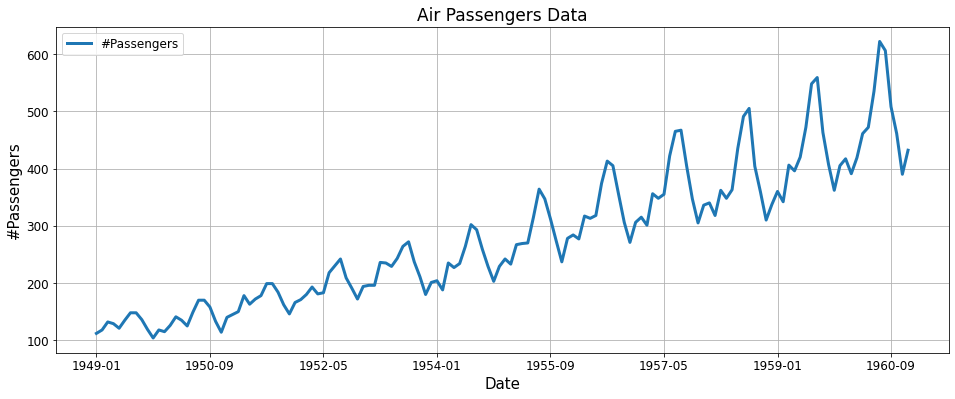

In [3]:
df = pd.read_csv("https://storage.googleapis.com/codehub-data/1-lv2-11-1-AirPassengers.csv")
df.set_index(df.Month, inplace=True)

plot_series(
    df['#Passengers'], 
    title='Air Passengers Data',
    y_label='#Passengers',
    figsize=(16, 6)
)

The variance seems to be increasing with level. Let's apply log transformation on the data using `np.log`. The target is to make the variance of the data constant a


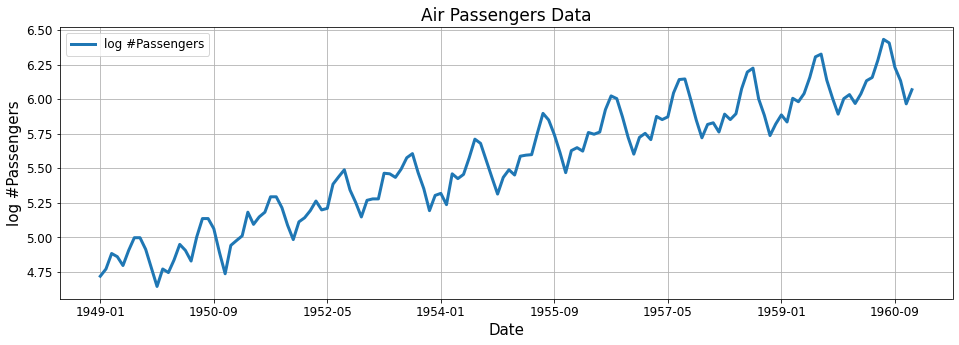

In [4]:
df['log#Passengers'] = np.log(df['#Passengers'].values)

plot_series(
    df['log#Passengers'], 
    title='Air Passengers Data',
    y_label='log #Passengers',
)

On observing the log transformed data, the variance seems to be stabilized.


## Rolling Operation

Rolling operation is one of the most famous operations in time series. The rolling operation creates a window of defined length and rolls it over the times series. Different calculations like mean, sum, standard deviation, etc. can be done on the window's data. Figure 1 demonstrates the rolling mean operation for a window of length 4 on a time series. 

<center>


<p>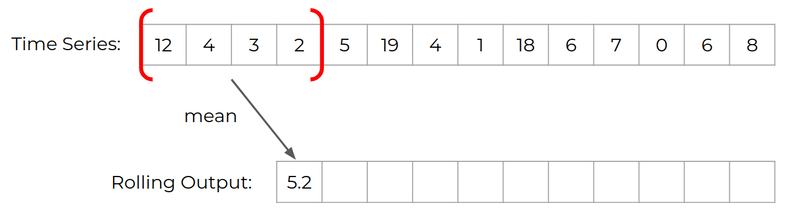</p>

Figure 1: Rolling operation of window size 4
</center>

Rolling mean operation is usually used to smooth the data. The result can be used to analyze the presence of a trend in the data. Let's try to apply rolling operation with window size equal to 12 (months in a year) on `log#Passengers`.


[]

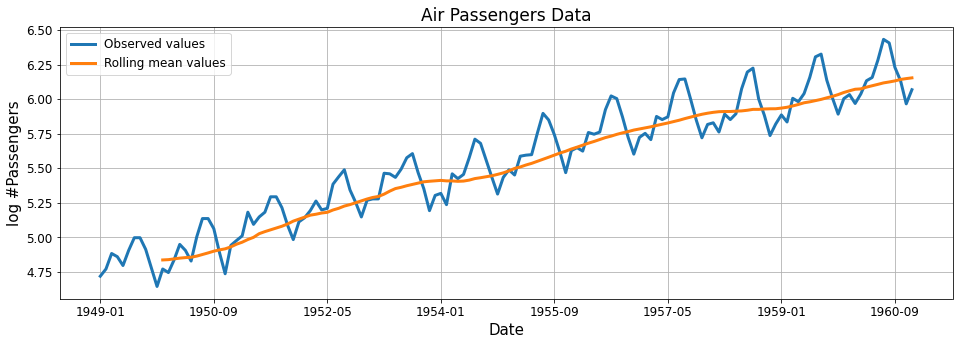

In [5]:
plot_series(
    df['log#Passengers'],
    title='Air Passengers Data',
    y_label='log #Passengers',
)

df['log#Passengers'].rolling(12).mean().plot(linewidth=3)
plt.legend(['Observed values', 'Rolling mean values'])
plt.grid()
plt.xlabel('Date')
plt.plot()

In the above figure, the blue curve shows the time-series values, and the orange curve shows the result of the rolling mean. The orange curve is shorter than the original time series by 11 timestamps since we're using 12 as the window length. It's because the first 12 timestamps are averaged to get the first result of the rolling mean. There's an evident trend present in the data. 


## Reducing Trend with Differencing

To remove the existing trend in the data, we can apply differencing on the data. Let's define the following two operators: backshift operator and difference operator. These operators are widely used in the Discrete-time Signal Processing domain. 


### Backshift Operator $(B)$
For a variable in time series, the backshift operator returns the variable one timestamp prior. It's denoted by $B$.

$$B X_t = X_{t - 1}$$

Applying the operator some $d$ number of times returns the variable $d$ timestamps before.

$$B^k X_d = X_{t - d}$$


### Difference Operator $(\nabla)$

For a variable in time series, the first order difference operator returns the difference between the given variable and the variable one timestamp prior. It's denoted by $\nabla$ and can be defined as:
$$
\begin{align*}
\nabla &= 1 - B \\
\end{align*}
$$ 

The application of the difference operator in $X_t$ can be decomposed as:
$$
\begin{align*}
\nabla X_t &= (1 - B) X_t
\\
&= X_t - B X_t
\\
&= X_t - X_{t - 1}
\end{align*}
$$ 


We can define d-order difference operator, denoted by $\nabla ^d$, as
$$
\nabla ^d = (1 - B)^d
$$


For a time series $X = \{ x_t \} _{t=0} ^T$, the result of difference operation is $Y = \{ y_t \} _{t=1} ^T = \{ x_t - x_{t-1} \} _{t=1} ^T$. The length of $X$ is $T + 1$ and $Y$ is $T$.  $y_t$ gives the change in value from $t - 1$ to $t$. Suppose $X$ shows a linearly increasing pattern. For the linearly increasing pattern, the change in values are approximately the same with some noise. Thus, for linear trend data $X$, the values in $Y$ will be approximately constant and the mean of $Y$ will be stabilized. Hence, we can infer that the differencing operation can reduce (remove) linear trend present in the data. For exponential trend patterns, higher order differencing needs to be applied.

Let's return to our `Air Passengers` data. We observed that the log-transformed data still has an increasing trend. Let's apply the difference operator on the time series. We can use the `diff` function from `statsmodels` for this.



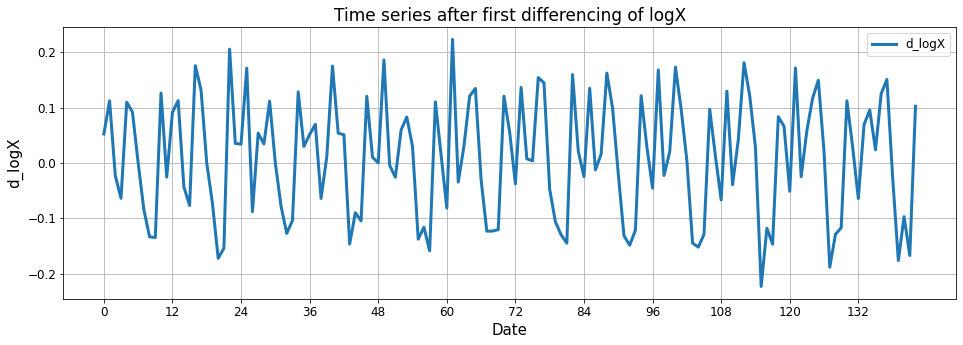

In [6]:
log_X = df['log#Passengers'].values

d_log_X = tools.diff(log_X)

plot_series(
    d_log_X,
    title = 'Time series after first differencing of logX', 
    y_label='d_logX',
)

The trend has been lost. The differenced values don't seem to have an increasing or decreasing trend. Sometimes, we may need to apply differencing further on the time series for removing the trends. For non seasonal data, we can apply the differencing operations in a loop until the data becomes stationary. We'll discuss the stationarity check in the last topic of this reading material. 


## Reducing Seasonality with Seasonal Differencing

Some standard time series like ARMA, ARIMA, etc. fit on non-seasonal data. You'll study these models in the coming chapters. To remove seasonality, we need to find the length of the season first. Let's analyze seasonality and then remove it using seasonal differencing next. 


### Analyzing Seasonality

We can observe seasonality in economic data like sales, revenues, etc. For example, sales of warm clothes are high in winter and less in summer and the distribution of sales over a year seems to be recurring every year. In a monthly sales data of warm clothes, we can observe strong dependence at lags multiples of 12, whereas, for quarterly sales data, the dependence is at lags multiples of 4. Natural phenomena like temperature, rainfall, etc. also follow strong seasonal patterns, matching with the seasonal changes. We may be able to guess the season for a given time series in some cases where some intuition and common sense of business and environmental factors hold. But there can be more complex situations where we can't have a reasonable guess of season. We present two ways of analyzing the seasonal pattern here. First, if we can guess the season for the easy case, we can validate it using seasonal decomposition based on the guessed season. And for the complex data, we may directly plot the ACF graph and study the nature of autocorrelations.  

Let's return to our `Air Passengers` data. The differenced data $d\_log\_X$ still has an observable seasonal pattern present. Observing the plots and since it's monthly data, we can guess the data has season of 12. Let's use a month-wise plot of each year to validate our guess. It can be done in pandas as follows.


[]

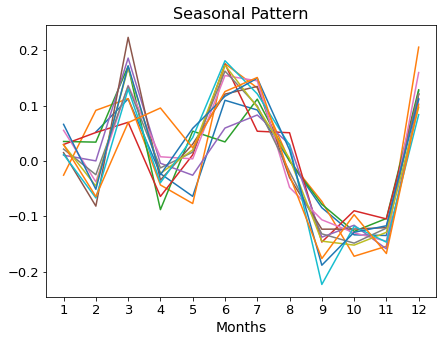

In [7]:
index = pd.DatetimeIndex(df.index) 
df['d_log#Passengers'] = np.concatenate([[np.nan],d_log_X])

pivot = pd.pivot_table(
    df,
    values='d_log#Passengers',
    index=index.month,
    columns=index.year
)

pivot.plot(figsize=(7, 5), fontsize=13)
plt.title('Seasonal Pattern', fontsize=16)
plt.ylabel('', fontsize=14)
plt.xlabel('Months', fontsize=14)
plt.xticks(range(1, 13))
plt.legend().remove()
plt.plot()

Observing the above plot for all the years at different months, we can see that the pattern is constant. 

Let's try ACF next. Had it been the case that the guessing season is hard, we'd have directly jumped into this step and analyzed ACF. Nonetheless, for the easy case, it provides additional support. We plot the ACF graph up to lag 48. The number of lags is solely based on the type and nature of data. For example, if we have data dumped fortnightly, we would like to see ACF up to lags equal to some number times 24. For monthly data, we can plot ACF up to lags equal to some number times 12. We can always refine our guess. Let's try ACF on the $d\_log\_X$.


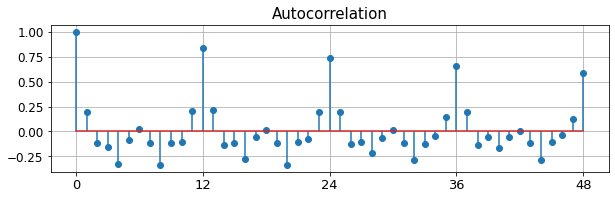

In [8]:
autocorrelations = stattools.acf(d_log_X, nlags=48, fft=False)
fig = plt.figure(figsize=(10, 2.7))
plt.stem(autocorrelations,  use_line_collection=True)
plt.title('Autocorrelation', fontsize=15)
plt.xticks(range(0, 49, 12), fontsize=13)
plt.grid()
plt.show()

On observing the ACF, we can see that the autocorrelations are significantly large at lags $12, 24, 36, ...$. It suggests that the season length is $12$, strengthening our prior belief.


### Seasonal Difference Operator $\nabla _s$

The seasonal difference operator gives the difference between the variable and the variable 1 season before it. It's denoted by $\nabla _s$ for season $s$ and defined as:  

$$
\begin{align*}
\nabla_s X_t &= (1 - B^s) X_t
\\
&= X_t - B^s X_t
\\
&= X_t - X_{t - s}
\end{align*}
$$

Let's try seasonal difference operation with season 12 on $d\_log\_X$.


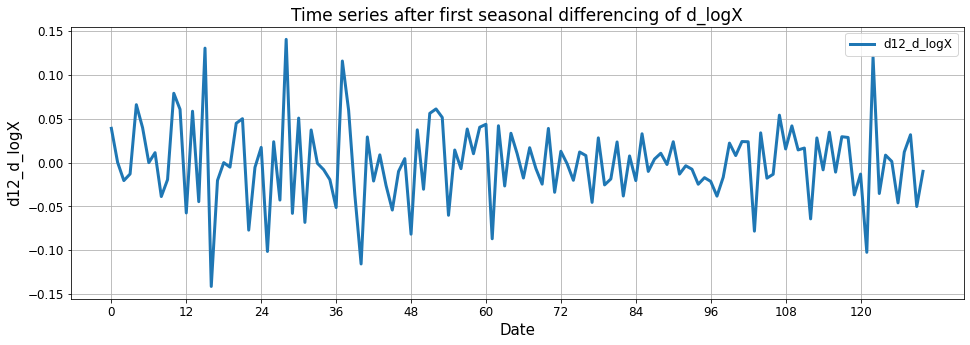

In [9]:
d12_d_log_X = tools.diff(
    d_log_X, 
    k_diff=0, 
    k_seasonal_diff=1, 
    seasonal_periods=12
)

plot_series(
    d12_d_log_X,
    title = 'Time series after first seasonal differencing of d_logX', 
    y_label='d12_d_logX',
)

The seasonality seems to be reduced.


## Stationarity Check - Augmented Dicky-Fuller (ADF) Test

You've studied stationarity in the previous chapter. Many TSA models are built with the underlying assumption that the time series is stationary. ADF test is a standard statistical test used to check whether a given time series is stationary or not. It falls into the category of unit root tests. The unit root is a characteristic of a time series that makes it non-stationary. The detailed concept of unit root and so ADF is out of the scope for this reading material. We'd instead like to use this test as a tool. The ADF test is fundamentally a statistical significance test. Thus it has two hypotheses:

> *Null Hypothesis*: The data has unit root (The data is not stationary). \\
*Alternative Hypothesis*: The data does not have a unit root (The data is stationary).

The task is to calculate a test statistic and the corresponding p-value. Then, the p-value is checked against a critical value. When the p-value is below the critical value, you can reject the null hypothesis and infer that the time series is stationary. On the contrary, if the p-value is larger than the critical value, you can't reject the null hypothesis, which will suggest that the data can be non-stationary. 

For this course, we'll use ADF as a black box using the `statsmodels.tsa.stattools.adfuller` function to obtain the p-value. We'll use  0.05 and 0.01 as critical values for different datasets. Let's check the stationarity of `d12_d_log_X`. 


In [10]:
p_value = stattools.adfuller(d12_d_log_X)[1]
p_value

0.0002485912311384052

In [11]:
p_value < 0.05

True

Since p_value is less than 0.05, the usual critical value. We can infer that the series `d12_d_log_X` is stationary.


In [12]:
p_value = stattools.adfuller(log_X)[1]
p_value

0.42236677477039125

In [13]:
p_value < 0.05

False

However, the p-value is more significant than 0.05 for `log_X`. Thus we cannot reject the null hypothesis. The data can be non-stationary. The `log_X` data had an increasing trend, which we saw earlier, which supports that the data is not stationary.


## Key Takeaways

1. Log transformation helps to stabilize variance in the data, in which the variance seems to be increasing or decreasing with the level.

2. Rolling operation rolls a fixed-sized window on the time series, on which different calculations like mean, standard deviation, etc. can be done.

3. Differencing can reduce the trend in the data, and the seasonal difference operation reduces seasonality. 

4. ADF test can be used to check whether a given time series is stationary or not.


## References

- Hyndman, R.J., & Athanasopoulos, G. (2018) Forecasting: principles and practice, 2nd edition, OTexts: Melbourne, Australia. OTexts.com/fpp2. Accessed on 10/26/2020.

    - * Check https://otexts.com/fpp2/transformations.html to understand more transformation techniques. 
